In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("np and pd are okay")

np and pd are okay


In [31]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [32]:
df = pd.read_csv("Bengaluru_House_Data.csv", usecols=["size","society","total_sqft","bath","balcony","price"])

In [33]:
df

,size,society,total_sqft,bath,balcony,price
0,2 BHK,Coomee,1056,2.0,1.0,39.07
1,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,3 BHK,NaN,1440,2.0,3.0,62.00
3,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...
13315,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,4 BHK,NaN,3600,5.0,NaN,400.00
13317,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   size        13304 non-null  str    
 1   society     7818 non-null   str    
 2   total_sqft  13320 non-null  str    
 3   bath        13247 non-null  float64
 4   balcony     12711 non-null  float64
 5   price       13320 non-null  float64
dtypes: float64(3), str(3)
memory usage: 624.5 KB


In [35]:
df.shape

(13320, 6)

In [36]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [37]:
df.isnull().sum()

size            16
society       5502
total_sqft       0
bath            73
balcony        609
price            0
dtype: int64

In [38]:
df["total_sqft"] = pd.to_numeric(df["total_sqft"], errors="coerce")

In [39]:
df["room_size"] = df["size"].str.split().str[0]
df["room_type"] = df["size"].str.split().str[1]

In [40]:
df.dtypes

size              str
society           str
total_sqft    float64
bath          float64
balcony       float64
price         float64
room_size      object
room_type      object
dtype: object

In [41]:
df.drop(columns=["size","society"],inplace=True)


In [42]:
df.sample(10)

,total_sqft,bath,balcony,price,room_size,room_type
2016,1034.0,2.0,3.0,40.00,2,BHK
5165,1205.0,2.0,1.0,40.00,2,BHK
12037,550.0,1.0,1.0,16.00,2,BHK
6114,1019.0,2.0,1.0,45.90,2,BHK
9182,1165.0,2.0,2.0,64.08,2,BHK
1457,1200.0,2.0,2.0,43.20,2,BHK
4888,1190.0,2.0,1.0,50.00,2,BHK
914,918.0,2.0,2.0,52.00,2,BHK
11755,1200.0,2.0,2.0,70.00,2,BHK
1222,2300.0,8.0,1.0,210.00,9,Bedroom


In [43]:
df.isnull().mean()*100

total_sqft    1.854354
bath          0.548048
balcony       4.572072
price         0.000000
room_size     0.120120
room_type     0.120120
dtype: float64

In [44]:
df.sample(5)

,total_sqft,bath,balcony,price,room_size,room_type
2628,1445.0,3.0,2.0,64.000,3,BHK
10351,NaN,1.0,0.0,27.565,1,BHK
5361,2100.0,3.0,NaN,252.000,3,BHK
3485,1080.0,2.0,1.0,44.000,2,BHK
13301,1454.0,3.0,3.0,71.500,3,BHK


In [45]:
x_train,x_test,y_train,y_test = train_test_split (
    df.drop(columns=["price"]),
    df["price"], test_size = 0.2, random_state = 2)

In [46]:
x_train

,total_sqft,bath,balcony,room_size,room_type
10835,1500.0,3.0,2.0,4,Bedroom
11102,1200.0,5.0,0.0,6,Bedroom
8070,1280.0,2.0,2.0,2,BHK
3305,1300.0,2.0,2.0,3,BHK
4870,1302.0,2.0,1.0,2,BHK
...,...,...,...,...,...
2514,1350.0,2.0,1.0,2,BHK
11798,1032.0,2.0,1.0,2,BHK
6637,700.0,2.0,1.0,2,BHK
2575,NaN,5.0,0.0,4,BHK


In [47]:
y_train

10835    162.00
11102    150.00
8070      60.16
3305      52.00
4870      66.00
          ...  
2514      67.50
11798     31.99
6637      35.07
2575     145.50
7336      70.00
Name: price, Length: 10656, dtype: float64

In [48]:
x_test

,total_sqft,bath,balcony,room_size,room_type
1873,5800.0,7.0,NaN,5,Bedroom
12128,1607.0,2.0,2.0,3,BHK
12633,1500.0,7.0,3.0,7,Bedroom
5769,2774.0,4.0,3.0,4,BHK
6084,2560.0,3.0,NaN,3,BHK
...,...,...,...,...,...
791,1179.0,2.0,1.0,2,BHK
972,1350.0,2.0,3.0,2,BHK
12423,1600.0,3.0,3.0,3,BHK
7242,26136.0,1.0,0.0,1,Bedroom


In [49]:
x_train

,total_sqft,bath,balcony,room_size,room_type
10835,1500.0,3.0,2.0,4,Bedroom
11102,1200.0,5.0,0.0,6,Bedroom
8070,1280.0,2.0,2.0,2,BHK
3305,1300.0,2.0,2.0,3,BHK
4870,1302.0,2.0,1.0,2,BHK
...,...,...,...,...,...
2514,1350.0,2.0,1.0,2,BHK
11798,1032.0,2.0,1.0,2,BHK
6637,700.0,2.0,1.0,2,BHK
2575,NaN,5.0,0.0,4,BHK


In [50]:
imputer1 = SimpleImputer(strategy="most_frequent")
imputer2 = SimpleImputer(strategy="mean")

In [51]:
trf=ColumnTransformer([
    ("imputer1",imputer1,['room_type']),
    ("imputer2",imputer2,["room_size","total_sqft","bath","balcony"])
],remainder="passthrough",verbose_feature_names_out=False)

In [52]:
trf.fit(x_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per

In [53]:
trf.set_output(transform="pandas")
x_train_trf=trf.transform(x_train)
x_test_trf=trf.transform(x_test)

In [54]:
ohe= OneHotEncoder(handle_unknown="ignore", sparse_output=False)
trf2=ColumnTransformer([
("ohe",ohe,["room_type"])],
remainder="passthrough",verbose_feature_names_out=False)

trf2.set_output(transform="pandas")
x_train_trf=trf2.fit_transform(x_train_trf)
x_test_trf=trf2.transform(x_test_trf)


In [55]:
trf3=ColumnTransformer([
  ("scaler",StandardScaler(),["room_size","total_sqft","bath","balcony"])],
  remainder="passthrough",verbose_feature_names_out=False)

trf3.set_output(transform="pandas")
trf3.fit_transform(x_train_trf)
trf3.transform(x_test_trf)

,room_size,total_sqft,bath,balcony,room_type_BHK,room_type_Bedroom,room_type_RK
1873,1.669966,3.396547,3.176641,-2.775140e-16,0.0,1.0,0.0
12128,0.143799,0.035174,-0.517841,5.189104e-01,1.0,0.0,0.0
12633,3.196132,-0.050604,3.176641,1.768722e+00,0.0,1.0,0.0
5769,0.906882,0.970715,0.959952,1.768722e+00,1.0,0.0,0.0
6084,0.143799,0.799159,0.221055,-2.775140e-16,1.0,0.0,0.0
...,...,...,...,...,...,...,...
791,-0.619284,-0.307938,-0.517841,-7.309013e-01,1.0,0.0,0.0
972,-0.619284,-0.170853,-0.517841,1.768722e+00,1.0,0.0,0.0
12423,0.143799,0.029562,0.221055,1.768722e+00,1.0,0.0,0.0
7242,-1.382367,19.699167,-1.256737,-1.980713e+00,0.0,1.0,0.0


In [56]:
x_train_trf.isnull().sum()



room_type_BHK        0
room_type_Bedroom    0
room_type_RK         0
room_size            0
total_sqft           0
bath                 0
balcony              0
dtype: int64

In [57]:
x_test_trf.isnull().sum()

room_type_BHK        0
room_type_Bedroom    0
room_type_RK         0
room_size            0
total_sqft           0
bath                 0
balcony              0
dtype: int64

In [58]:
x_train_trf.dtypes

room_type_BHK        float64
room_type_Bedroom    float64
room_type_RK         float64
room_size            float64
total_sqft           float64
bath                 float64
balcony              float64
dtype: object

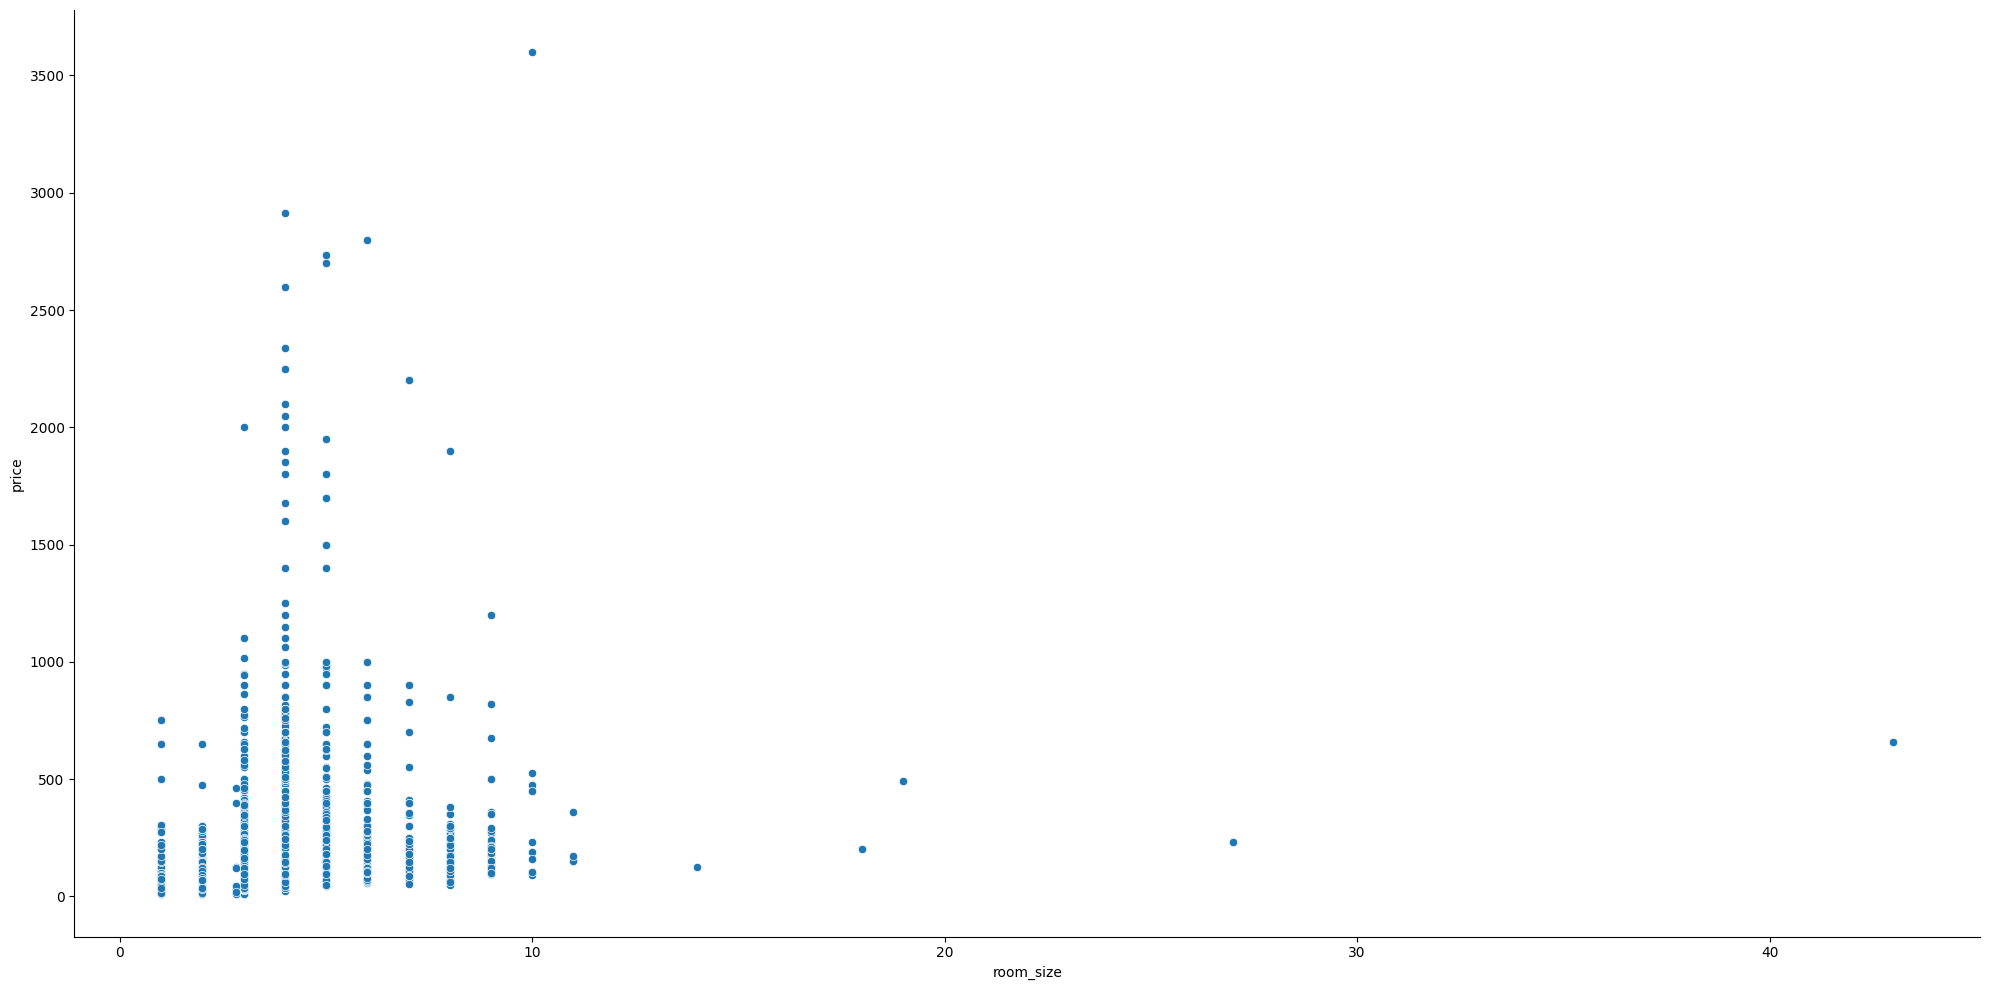

In [59]:
sns.relplot(data=x_train_trf, x="room_size", y=y_train, height=10,aspect=2,kind= "scatter")

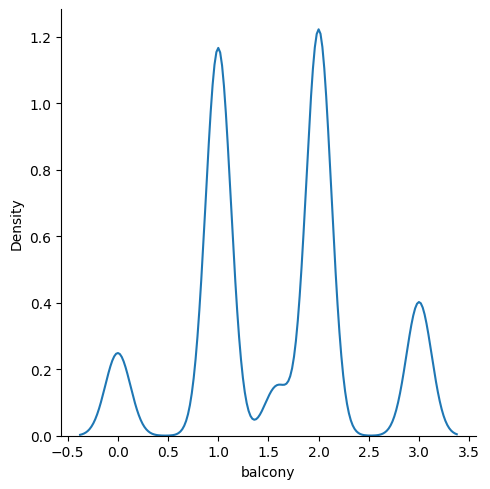

In [60]:
sns.displot( data=x_train_trf, x= "balcony",kind='kde')

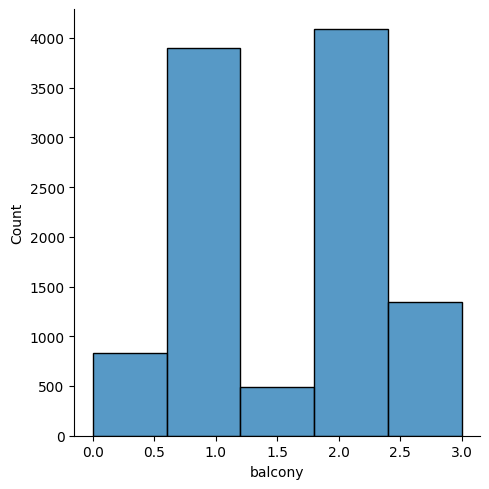

In [61]:
sns.displot(data=x_train_trf, x="balcony",kind='hist',bins=5)

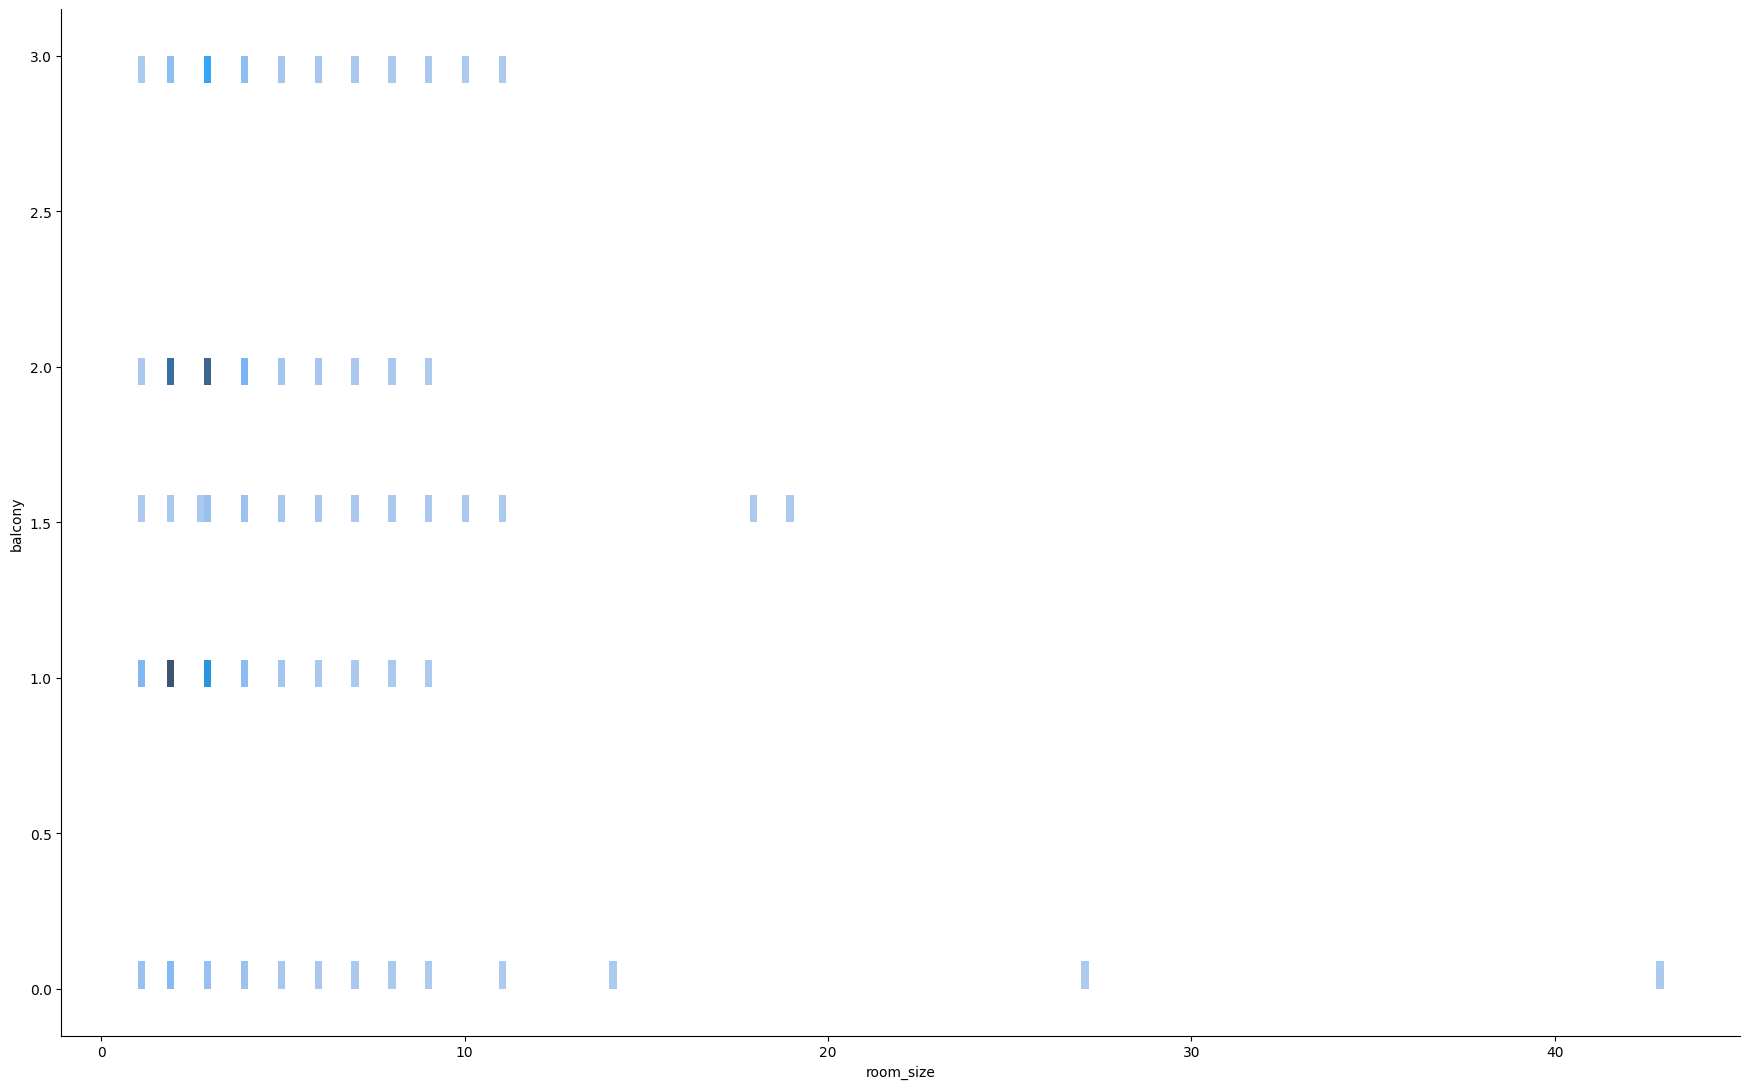

In [62]:
sns.displot(data=x_train_trf, x="room_size", y='balcony',kind='hist',height=11, aspect=1.6)

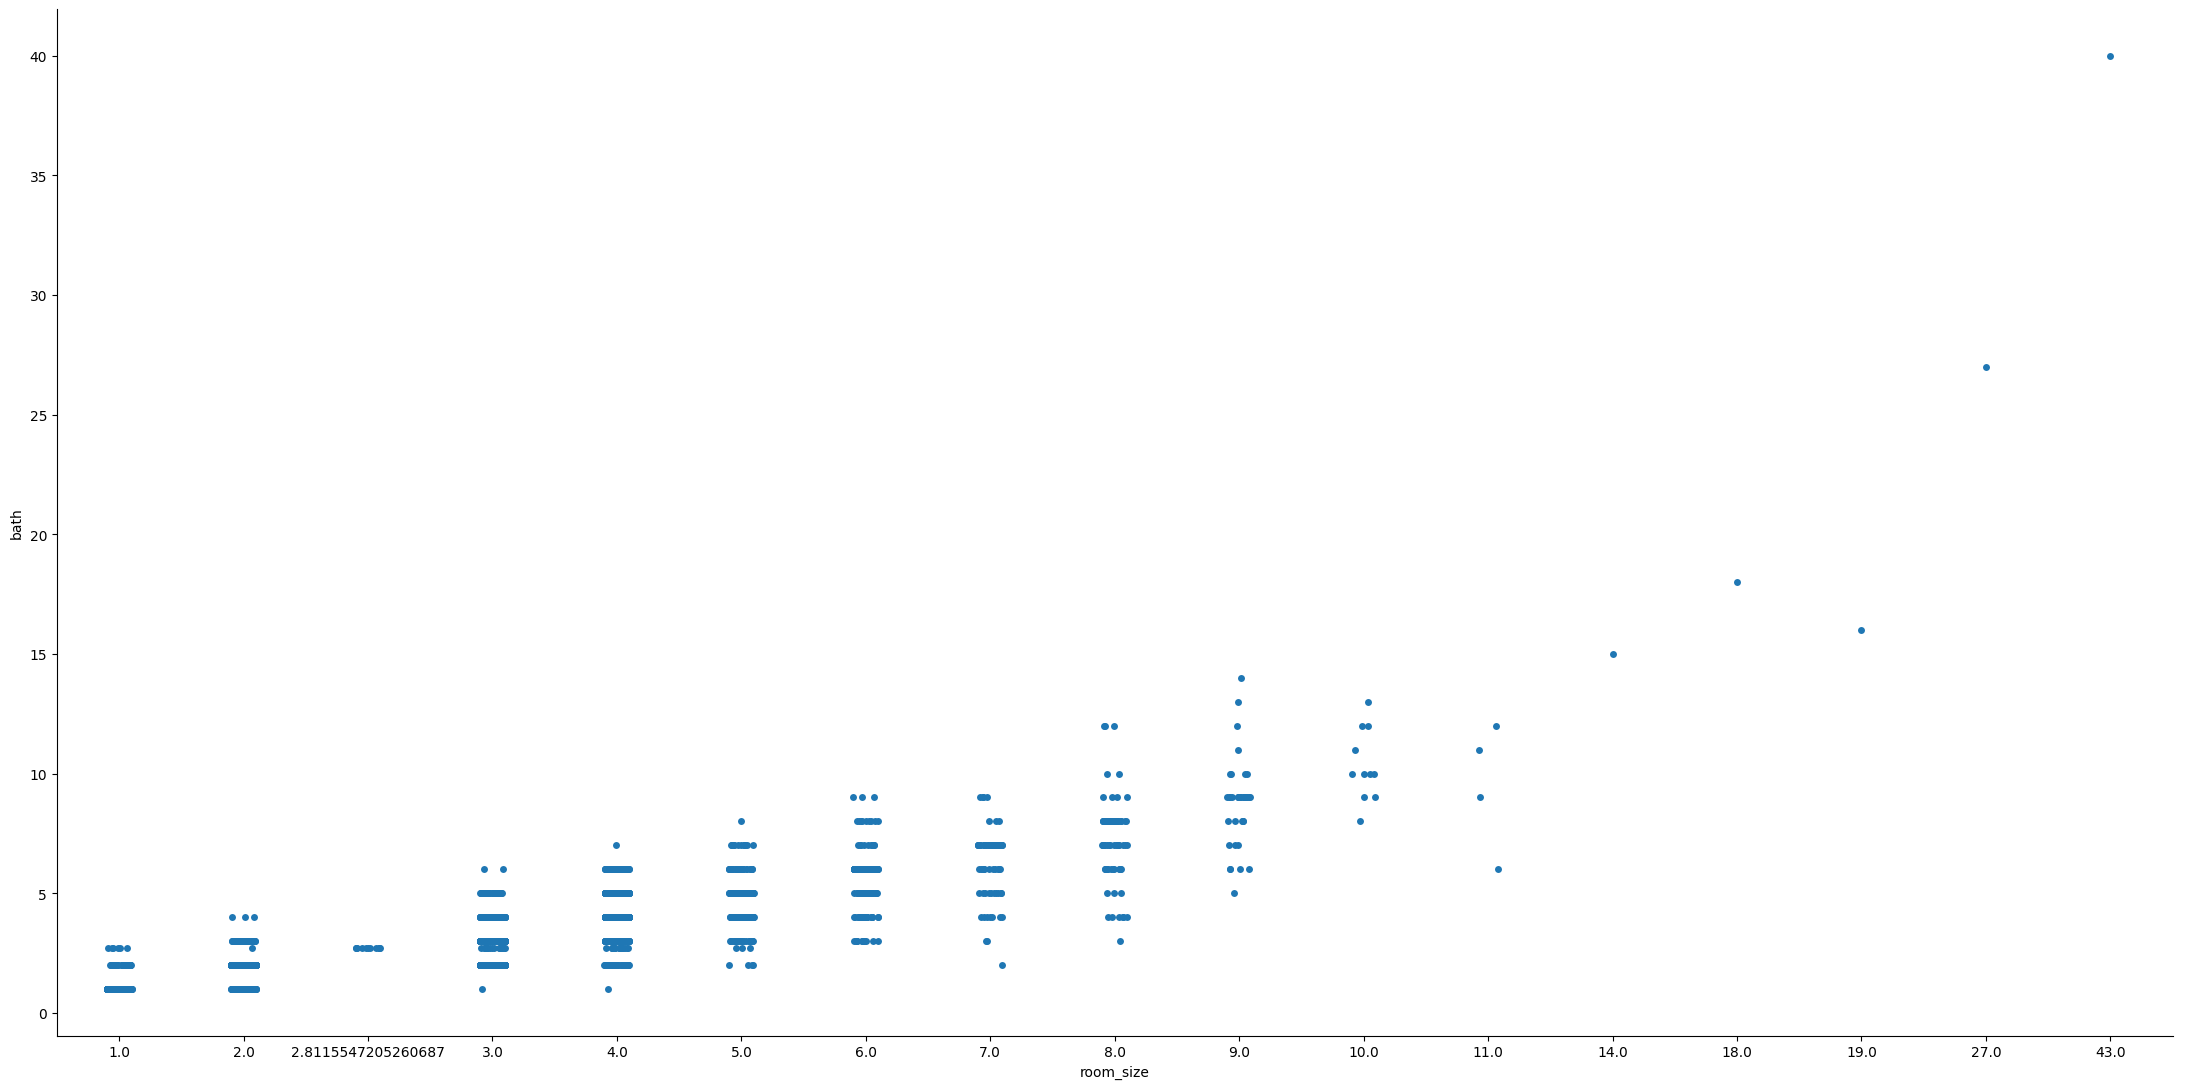

In [63]:
sns.catplot(data=x_train_trf,x="room_size",y="bath",kind='strip',aspect=2,height=11)

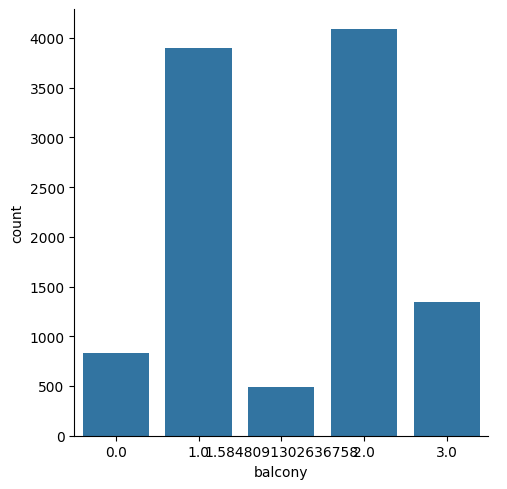

In [64]:
sns.catplot(data=x_train_trf, x='balcony',kind='count')

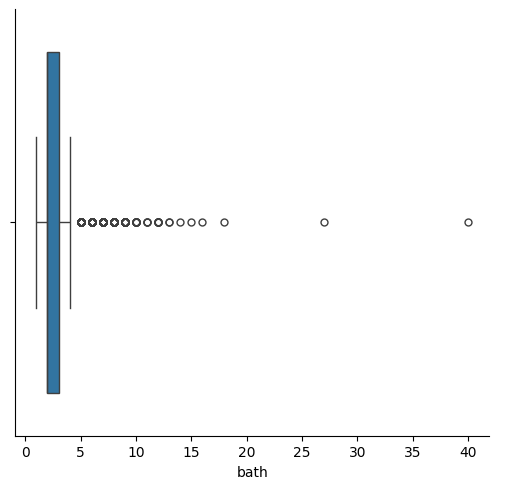

In [65]:
sns.catplot(data=x_train_trf,x='bath',kind='box')

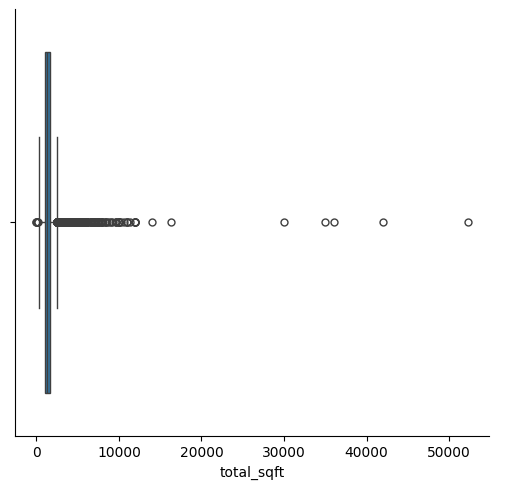

In [66]:
sns.catplot(data=x_train_trf,x='total_sqft',kind='box')

In [67]:
clf=LinearRegression()
clf.fit(x_train_trf,y_train)
y_pred=clf.predict(x_test_trf)
r2_score(y_test,y_pred)

0.44814480913358046

In [68]:
import os
os.getcwd()

'C:\\Users\\Administrator\\Documents\\GenAI\\ML_Projects'

In [69]:
!git init

Initialized empty Git repository in C:/Users/Administrator/Documents/GenAI/ML_Projects/.git/


In [70]:
!git status

On branch master

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/
	Bengaluru_House_Data.csv
	Result.ipynb
	Result.py
	Student_performance.ipynb
	Student_performance.py
	first_ml project.ipynb
	first_ml_project.py
	math_score.ipynb
	pct2.ipynb
	pct2.py

nothing added to commit but untracked files present (use "git add" to track)


In [71]:
!git add Bengaluru_House_Data.csv
!git add first_ml_project.ipynb
!git add first_ml_project.py

fatal: pathspec 'first_ml_project.ipynb' did not match any files
